In [1]:
# Librairies nécessaires
import os
import pickle
!pip install fasttext
import fasttext
import re
!pip install --upgrade top2vec gensim
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.fasttext import load_facebook_model
from top2vec import Top2Vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 6.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498213 sha256=0d6fac1d1aa6bbd35668ae761e963bcdd4e805df59310c758aef2dcc09043754
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
project_path = "/content/drive/MyDrive/TrustPilot_Project"
preprocessed_path = project_path + "/data/preprocessed"
embeddings_path = project_path + "/embeddings"

In [4]:
# Load preprocessed dataset
with open(os.path.join(preprocessed_path, "dataset_preprocessed.pkl"), "rb") as f:
    df = pickle.load(f)

In [6]:
# Load preprocessed dataset
with open(os.path.join(preprocessed_path, "dataset_preprocessed.pkl"), "rb") as f:
    df = pickle.load(f)

In [7]:
# load FastText Embedding
with open(os.path.join(embeddings_path, "emb_ft_full.pkl"), "rb") as f:
  ft_embeddings = pickle.load(f)

In [10]:
docs = df['comment_clean'].tolist()

In [11]:
# création du modéle Top2Vec
model = Top2Vec(
    documents=docs,
    embedding_model='distiluse-base-multilingual-cased',  # or 'doc2vec' (smaller, faster)
    speed='learn',
    workers=4
)

2025-11-18 18:26:05,549 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
2025-11-18 18:26:10,317 - top2vec - INFO - Downloading distiluse-base-multilingual-cased model
INFO:top2vec:Downloading distiluse-base-multilingual-cased model
2025-11-18 18:26:14,301 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2025-11-18 18:26:39,072 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2025-11-18 18:26:50,745 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was 

In [12]:
# Exploration des topics
print("Number of topics:", model.get_num_topics())

Number of topics: 70


In [13]:
topic = model.get_topics(3)
topic

(array([['mail', 'email', 'mails', 'remboursements', 'cliente',
         'clientele', 'remboursement', 'clients', 'client', 'refuse',
         'plainte', 'envoyes', 'remboursent', 'envoye', 'annulation',
         'envoie', 'envoyer', 'facture', 'paiement', 'amazon',
         'rembourses', 'incompetence', 'envoi', 'rembourse', 'adresse',
         'payer', 'commande', 'reclamation', 'retard', 'remboursee',
         'annuler', 'rembourser', 'incompetent', 'commandes',
         'mecontente', 'commandees', 'non', 'gestion', 'reclamations',
         'refuser', 'annulee', 'charge', 'incompetents', 'decevant',
         'reception', 'dedommagement', 'scandaleux', 'honte',
         'fournisseur', 'reconditionne'],
        ['refuse', 'refuser', 'inacceptable', 'incomplete', 'article',
         'mecontente', 'regrette', 'articles', 'inadmissible',
         'incompetent', 'commande', 'excuse', 'incompetence', 'commandes',
         'commandees', 'mail', 'annulation', 'reclamation', 'plainte',
      

In [15]:
import pandas as pd
topic_sizes, topic_nums = model.get_topic_sizes()
topic_df = pd.DataFrame({
    "Topic": topic_nums,
    "Number of Reviews": topic_sizes
}).sort_values(by="Number of Reviews", ascending=False)

print(topic_df.head(10))

   Topic  Number of Reviews
0      0               3066
1      1                849
2      2                639
3      3                513
4      4                454
5      5                453
6      6                398
7      7                364
8      8                293
9      9                286


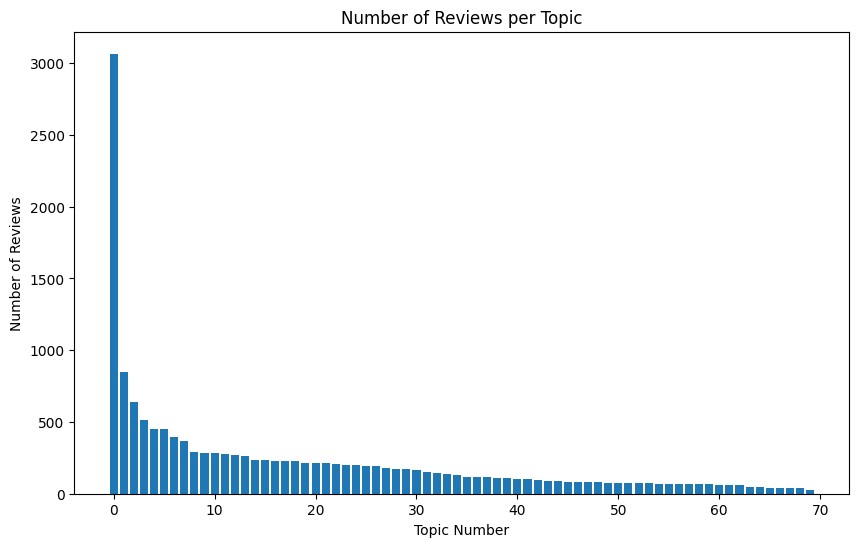

In [16]:
# visualation des topics
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(topic_df['Topic'], topic_df['Number of Reviews'])
plt.xlabel('Topic Number')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews per Topic')
plt.show()

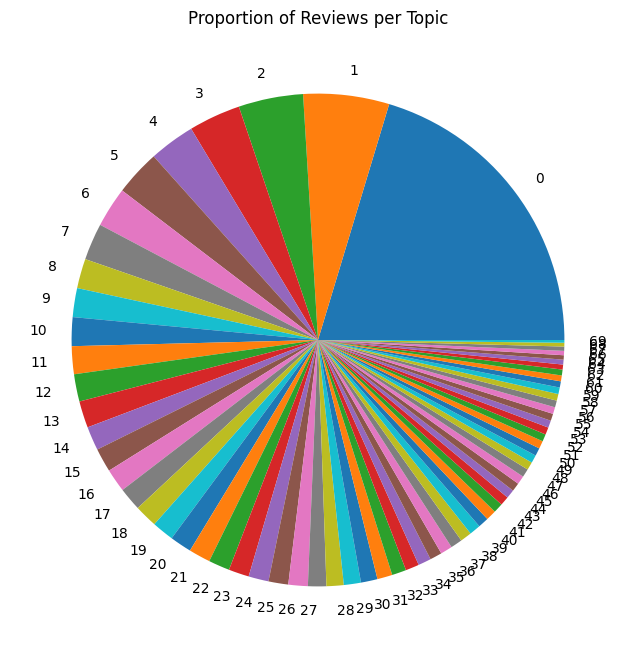

In [17]:
plt.figure(figsize=(8,8))
plt.pie(topic_df['Number of Reviews'], labels=topic_df['Topic'])
plt.title('Proportion of Reviews per Topic')
plt.show()

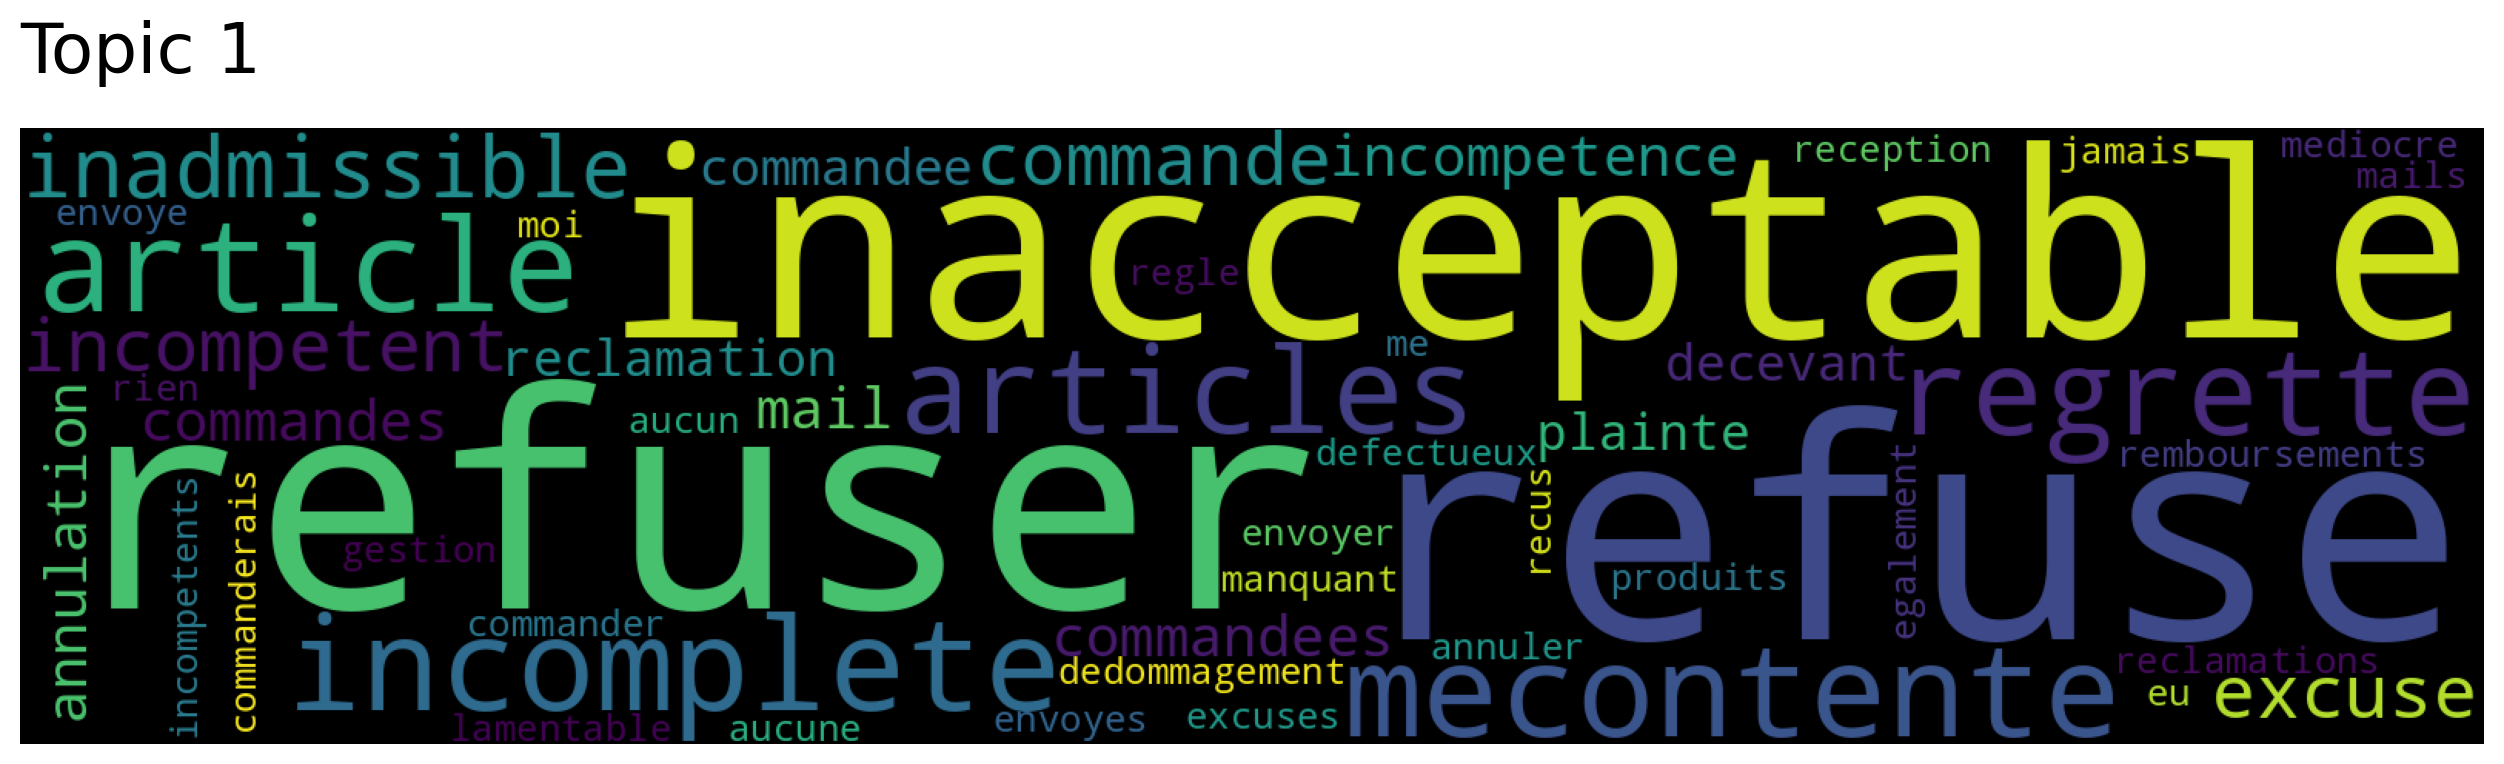

In [18]:
# Visual evalution
#génération wordcloud pour un topic
model.generate_topic_wordcloud(1)